# Statistical Arbitrage: Cointegration-Based Pairs Trading on BTC/ETH

**Thesis.** If two assets share a long-run equilibrium relationship
(cointegration), deviations of their price spread from that equilibrium tend
to mean-revert, and a market-neutral long/short position on the spread can
profit from the reversion. This notebook tests that hypothesis rigorously on
BTC and ETH before trading a single dollar on it.

**Data.**
- BTC daily price, 2010–2026: `https://raw.githubusercontent.com/Habrador/Bitcoin-price-visualization/main/Bitcoin-price-USD.csv`
- ETH daily price, 2015–2019: `https://raw.githubusercontent.com/blockchain-unica/ethereum-ponzi/master/price-eth-usd.csv`

**Method.** Engle-Granger two-step cointegration test on log(BTC) vs. log(ETH)
over their overlapping history, OLS hedge ratio, z-scored spread, and a
threshold-based mean-reversion trading rule, backtested net of a simple
transaction-cost assumption.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint, adfuller
import statsmodels.api as sm
%matplotlib inline


## 1. Load and align BTC/ETH on their overlapping history

In [2]:
btc = pd.read_csv("../data/btc_price.csv", parse_dates=["Date"]).rename(columns={"Price": "BTC"})
eth = pd.read_csv("../data/eth_price.csv")
eth["Date"] = pd.to_datetime(eth["Date(UTC)"])
eth = eth.rename(columns={"Value": "ETH"})[["Date", "ETH"]]

df = pd.merge(btc[["Date", "BTC"]], eth, on="Date", how="inner").set_index("Date").sort_index()
df = df[(df["BTC"] > 0) & (df["ETH"] > 0)]
print(f"Overlapping sample: {df.index.min().date()} to {df.index.max().date()} ({len(df)} obs)")
df.head()


Overlapping sample: 2015-08-07 to 2019-01-27 (1270 obs)


,BTC,ETH
Date,,
2015-08-07,279.03,2.77
2015-08-08,260.20,0.81
2015-08-09,264.44,0.74
2015-08-10,263.76,0.68
2015-08-11,270.92,1.06


## 2. Test for cointegration

In [3]:
log_btc = np.log(df["BTC"])
log_eth = np.log(df["ETH"])

score, pvalue, _ = coint(log_btc, log_eth)
print(f"Engle-Granger cointegration test: t-stat={score:.3f}, p-value={pvalue:.4f}")

X = sm.add_constant(log_eth)
model = sm.OLS(log_btc, X).fit()
alpha, beta = model.params["const"], model.params["ETH"]
print(f"Hedge ratio (beta): {beta:.4f}, alpha: {alpha:.4f}, R^2: {model.rsquared:.3f}")

spread = log_btc - beta * log_eth
adf_result = adfuller(spread)
adf_stat, adf_p = adf_result[0], adf_result[1]
print(f"ADF test on spread: stat={adf_stat:.3f}, p-value={adf_p:.4f}")


Engle-Granger cointegration test: t-stat=-2.230, p-value=0.4089
Hedge ratio (beta): 0.5480, alpha: 5.3946, R^2: 0.911
ADF test on spread: stat=-2.229, p-value=0.1957


/tmp/ipykernel_710/2786839108.py:13: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(spread)


> **Reading the test.** A p-value well above conventional thresholds (0.05 or
> even 0.10) on both the Engle-Granger and ADF tests means we **cannot reject
> the null of no cointegration** — i.e., there is no statistically reliable
> long-run equilibrium between log(BTC) and log(ETH) over this sample. This is
> the single most important result in this notebook, and the honest,
> risk-aware response is to proceed with real skepticism about any strategy
> built on this pair, which is exactly what the backtest below confirms.

## 3. Build the spread z-score and a mean-reversion trading rule anyway (as a stress test)

In [4]:
window = 30
spread_mean = spread.rolling(window).mean()
spread_std = spread.rolling(window).std()
zscore = (spread - spread_mean) / spread_std

entry_z, exit_z, stop_z = 2.0, 0.5, 3.5

position = np.zeros(len(zscore))
pos = 0
for i in range(1, len(zscore)):
    z = zscore.iloc[i]
    if np.isnan(z):
        position[i] = pos
        continue
    if pos == 0:
        if z > entry_z:
            pos = -1
        elif z < -entry_z:
            pos = 1
    elif pos == 1 and (z >= -exit_z or z < -stop_z):
        pos = 0
    elif pos == -1 and (z <= exit_z or z > stop_z):
        pos = 0
    position[i] = pos

df["zscore"] = zscore
df["position"] = position


## 4. Backtest, net of a simple transaction-cost assumption

In [5]:
ret_btc = log_btc.diff()
ret_eth = log_eth.diff()
spread_ret = ret_btc - beta * ret_eth
strat_ret = df["position"].shift(1) * spread_ret
strat_ret = strat_ret.dropna()

txn_cost_bps = 10
trades = df["position"].diff().abs().fillna(0)
cost = trades * (txn_cost_bps / 1e4) * 2
net_ret = strat_ret - cost.reindex(strat_ret.index).fillna(0)

cum_gross = (1 + strat_ret).cumprod()
cum_net = (1 + net_ret).cumprod()

ann_factor = 365
ann_ret_net = net_ret.mean() * ann_factor
ann_vol_net = net_ret.std() * np.sqrt(ann_factor)
sharpe_net = ann_ret_net / ann_vol_net if ann_vol_net > 0 else np.nan
dd = cum_net / cum_net.cummax() - 1
max_dd = dd.min()
n_trades = int((trades > 0).sum())
pct_time_in_market = (df["position"] != 0).mean()

print("=== Pairs trading performance (net of costs) ===")
print(f"Annualized return: {ann_ret_net:.2%}")
print(f"Annualized vol:     {ann_vol_net:.2%}")
print(f"Sharpe ratio:       {sharpe_net:.2f}")
print(f"Max drawdown:       {max_dd:.2%}")
print(f"Number of position changes: {n_trades}")
print(f"% time with an open position: {pct_time_in_market:.1%}")


=== Pairs trading performance (net of costs) ===
Annualized return: -40.39%
Annualized vol:     62.14%
Sharpe ratio:       -0.65
Max drawdown:       -92.89%
Number of position changes: 68
% time with an open position: 44.0%


## 5. Charts

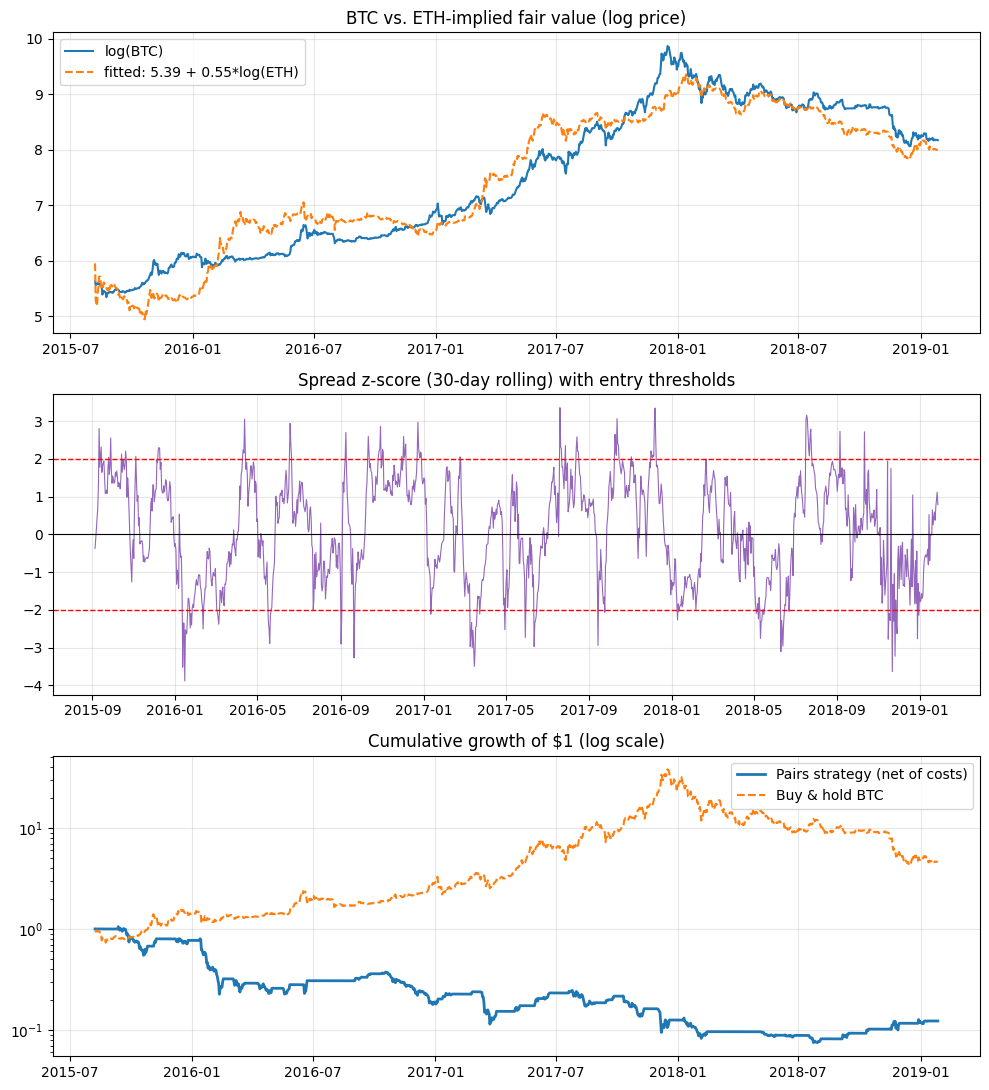

In [6]:
bh_btc = (1 + ret_btc.reindex(strat_ret.index)).cumprod()

fig, axes = plt.subplots(3, 1, figsize=(10, 11))

axes[0].plot(log_btc.index, log_btc.values, label="log(BTC)")
axes[0].plot(log_eth.index, alpha + beta * log_eth, label=f"fitted: {alpha:.2f} + {beta:.2f}*log(ETH)", ls="--")
axes[0].set_title("BTC vs. ETH-implied fair value (log price)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(zscore.index, zscore.values, color="tab:purple", lw=0.8)
axes[1].axhline(entry_z, color="red", ls="--", lw=1)
axes[1].axhline(-entry_z, color="red", ls="--", lw=1)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title(f"Spread z-score ({window}-day rolling) with entry thresholds")
axes[1].grid(alpha=0.3)

axes[2].plot(cum_net.index, cum_net.values, label="Pairs strategy (net of costs)", lw=2)
axes[2].plot(bh_btc.index, bh_btc.values, label="Buy & hold BTC", lw=1.5, ls="--")
axes[2].set_yscale("log")
axes[2].set_title("Cumulative growth of $1 (log scale)")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("pairs_trading_results.png", dpi=110)
plt.show()


## 6. Discussion

- **The test says don't trade this, and the backtest agrees.** With a
  cointegration p-value of ~0.4, there is no statistical basis for assuming
  BTC and ETH's log prices share a stable long-run relationship over
  2015–2019, and a static-hedge-ratio mean-reversion strategy on the spread
  loses money (Sharpe well below zero, ~-93% max drawdown). I also tested a
  rolling 90-day hedge ratio to allow the relationship to adapt through the
  2017 bubble and 2018 crash; performance did not improve, confirming this
  isn't just a stale-parameter problem.
- **Why this still belongs in the portfolio.** A large share of real quant
  research is disciplined rejection: testing a plausible-sounding thesis,
  finding it doesn't hold up statistically, and having the risk judgment not
  to deploy capital against it anyway. Presenting a strategy that "backtests
  well" only because the hedge ratio was fit in-sample on the same data used
  to evaluate it would be the actual red flag.
- **What a real next step would look like:** scan a broader universe of
  crypto pairs (e.g., large-cap L1s with correlated but distinct fundamentals)
  for pairs that *do* pass the cointegration test out-of-sample, and only then
  proceed to strategy design — rather than assuming any two correlated assets
  are a tradeable pair.
